<a href="https://colab.research.google.com/github/NKontemeniotou/ML-Based-Airline-Satisfaction-Prediction/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
target= 'satisfaction'
numeric_features = ['Flight Distance', 'Arrival Delay in Minutes','Age','Inflight wifi service','Departure/Arrival time convenient','Ease of Online booking','Gate location','Food and drink','Online boarding', 'Seat comfort','Inflight entertainment','On-board service','Leg room service','Baggage handling','Checkin service','Inflight service','Cleanliness']
binary_features = ['Gender', 'Customer Type', 'Type of Travel']
categorical_nominal = ['Class']

In [ ]:
import sys, platform
print(platform.python_version())   # π.χ. 3.10.12
print(sys.version)                # αναλυτικό string
print(sys.version_info)           # tuple (major, minor, micro)


3.12.11
3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
sys.version_info(major=3, minor=12, micro=11, releaselevel='final', serial=0)


In [ ]:
from sklearn.utils import resample

df_majority=df[df[target]==0]
df_minority=df[df[target]==1]

df_majority_downsampled=resample(df_majority,replace=False,n_samples=15000,random_state=42)
df_minority_downsampled=resample(df_minority,replace=False,n_samples=15000,random_state=42)

df_sampled=pd.concat([df_majority_downsampled,df_minority_downsampled]).sample(frac=1, random_state=42).reset_index(drop=True)
X_final=df_sampled.drop(columns='satisfaction')
y_final=df_sampled[target]
df_sampled.to_excel('final3.xlsx', index=False)
files.download('final3.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded=files.upload()
import pandas as pd
df=pd.read_excel("final3.xlsx")


Saving final3.xlsx to final3.xlsx


In [ ]:
x=df.drop(columns=['satisfaction','Departure Delay in Minutes'])
y=df[target]

In [ ]:
!pip install shutup

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold,KFold,RepeatedStratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

import shutup
import logging
import warnings
warnings.filterwarnings(action='ignore',category=FutureWarning)
shutup.please()
for name in logging.Logger.manager.loggerDict.keys():
    logging.getLogger(name).setLevel(logging.CRITICAL)


1 χαρακτηριστικά -> mean CV score: 0.7132
2 χαρακτηριστικά -> mean CV score: 0.8048
3 χαρακτηριστικά -> mean CV score: 0.9150
4 χαρακτηριστικά -> mean CV score: 0.9190
5 χαρακτηριστικά -> mean CV score: 0.9348
6 χαρακτηριστικά -> mean CV score: 0.9474
7 χαρακτηριστικά -> mean CV score: 0.9520
8 χαρακτηριστικά -> mean CV score: 0.9540
9 χαρακτηριστικά -> mean CV score: 0.9550
10 χαρακτηριστικά -> mean CV score: 0.9576
11 χαρακτηριστικά -> mean CV score: 0.9575
12 χαρακτηριστικά -> mean CV score: 0.9576
13 χαρακτηριστικά -> mean CV score: 0.9582
14 χαρακτηριστικά -> mean CV score: 0.9587
15 χαρακτηριστικά -> mean CV score: 0.9591
16 χαρακτηριστικά -> mean CV score: 0.9595
17 χαρακτηριστικά -> mean CV score: 0.9598
18 χαρακτηριστικά -> mean CV score: 0.9597
19 χαρακτηριστικά -> mean CV score: 0.9598
20 χαρακτηριστικά -> mean CV score: 0.9598
21 χαρακτηριστικά -> mean CV score: 0.9598
22 χαρακτηριστικά -> mean CV score: 0.9598
23 χαρακτηριστικά -> mean CV score: 0.9598


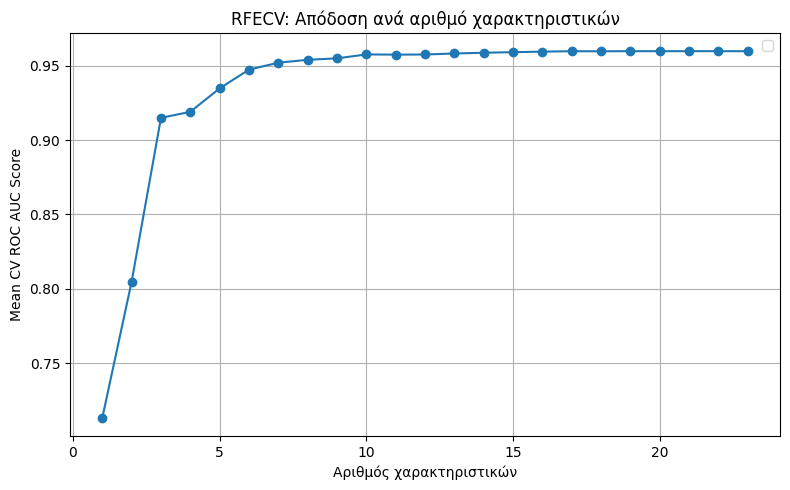

Επιλεγμένα χαρακτηριστικά:
Flight Distance
Arrival Delay in Minutes
Inflight wifi service
Departure/Arrival time convenient
Ease of Online booking
Gate location
Food and drink
Online boarding
Seat comfort
Inflight entertainment
On-board service
Leg room service
Baggage handling
Checkin service
Inflight service
Cleanliness
Gender
Customer Type
Type of Travel
Class_0
Class_1
Class_2


In [ ]:
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features),
        ('nom', OneHotEncoder(handle_unknown='ignore'), categorical_nominal)
    ]
)
clf=LogisticRegression(C=0.01)
cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=2)
rfecv=RFECV(estimator=clf,cv=cv,scoring='roc_auc')

pipeline=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('feature_selection',rfecv)
    ]
)
pipeline.fit(x,y)
selector=pipeline.named_steps['feature_selection']
scores=selector.cv_results_['mean_test_score']

for i,score in enumerate(scores,start=1):
  print(f"{i} χαρακτηριστικά -> mean CV score: {score:.4f}")
scores=selector.cv_results_['mean_test_score']
best_n=selector.n_features_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(scores) + 1), scores, marker='o', linestyle='-')
plt.xlabel("Αριθμός χαρακτηριστικών")
plt.ylabel("Mean CV ROC AUC Score")
plt.title("RFECV: Απόδοση ανά αριθμό χαρακτηριστικών")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

preprocessor.fit(x)
num_features = preprocessor.named_transformers_['num'].get_feature_names_out(numeric_features)
bin_features = binary_features
nom_features = preprocessor.named_transformers_['nom'].get_feature_names_out(categorical_nominal)
all_feature_names = np.concatenate([num_features, bin_features, nom_features])
selected_mask = selector.support_
feature_ranks = selector.ranking_
selected_features = all_feature_names[selector.support_]
print("Επιλεγμένα χαρακτηριστικά:")
for f in selected_features:
    print(f)



1 χαρακτηριστικά -> mean CV score: 0.8344
2 χαρακτηριστικά -> mean CV score: 0.8937
3 χαρακτηριστικά -> mean CV score: 0.9473
4 χαρακτηριστικά -> mean CV score: 0.9698
5 χαρακτηριστικά -> mean CV score: 0.9769
6 χαρακτηριστικά -> mean CV score: 0.9789
7 χαρακτηριστικά -> mean CV score: 0.9802
8 χαρακτηριστικά -> mean CV score: 0.9836
9 χαρακτηριστικά -> mean CV score: 0.9840
10 χαρακτηριστικά -> mean CV score: 0.9847
11 χαρακτηριστικά -> mean CV score: 0.9852
12 χαρακτηριστικά -> mean CV score: 0.9855
13 χαρακτηριστικά -> mean CV score: 0.9865
14 χαρακτηριστικά -> mean CV score: 0.9867
15 χαρακτηριστικά -> mean CV score: 0.9872
16 χαρακτηριστικά -> mean CV score: 0.9880
17 χαρακτηριστικά -> mean CV score: 0.9882
18 χαρακτηριστικά -> mean CV score: 0.9883
19 χαρακτηριστικά -> mean CV score: 0.9886
20 χαρακτηριστικά -> mean CV score: 0.9884
21 χαρακτηριστικά -> mean CV score: 0.9883
22 χαρακτηριστικά -> mean CV score: 0.9880
23 χαρακτηριστικά -> mean CV score: 0.9879


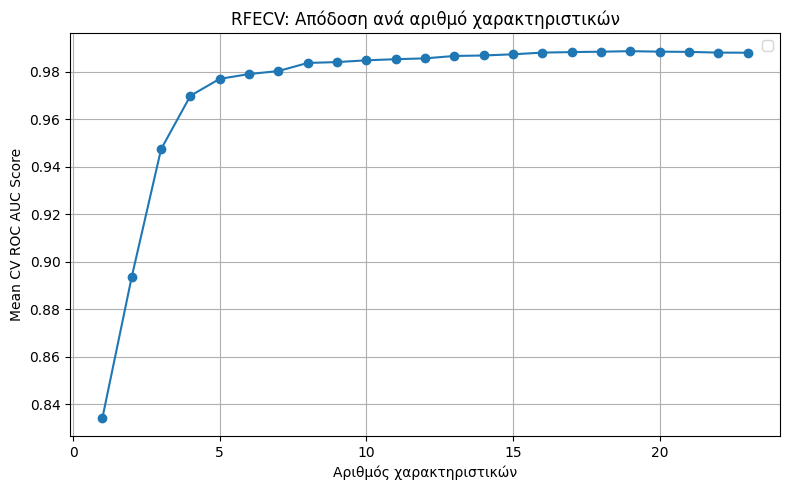

Επιλεγμένα χαρακτηριστικά:
Flight Distance
Age
Inflight wifi service
Departure/Arrival time convenient
Ease of Online booking
Gate location
Online boarding
Seat comfort
Inflight entertainment
On-board service
Leg room service
Baggage handling
Checkin service
Inflight service
Cleanliness
Customer Type
Type of Travel
Class_0
Class_1


In [ ]:
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('bin', 'passthrough', binary_features),
        ('nom', OneHotEncoder(handle_unknown='ignore'), categorical_nominal)
    ]
)
clf= RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42)

cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=2)
rfecv=RFECV(estimator=clf,cv=cv,scoring='roc_auc')

pipeline=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('feature_selection',rfecv)
    ]
)
pipeline.fit(x,y)
selector=pipeline.named_steps['feature_selection']
scores=selector.cv_results_['mean_test_score']

for i,score in enumerate(scores,start=1):
  print(f"{i} χαρακτηριστικά -> mean CV score: {score:.4f}")
scores=selector.cv_results_['mean_test_score']
best_n=selector.n_features_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(scores) + 1), scores, marker='o', linestyle='-')
plt.xlabel("Αριθμός χαρακτηριστικών")
plt.ylabel("Mean CV ROC AUC Score")
plt.title("RFECV: Απόδοση ανά αριθμό χαρακτηριστικών")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

preprocessor.fit(x)
num_features = preprocessor.named_transformers_['num'].get_feature_names_out(numeric_features)
bin_features = binary_features
nom_features = preprocessor.named_transformers_['nom'].get_feature_names_out(categorical_nominal)
all_feature_names = np.concatenate([num_features, bin_features, nom_features])
selected_mask = selector.support_
feature_ranks = selector.ranking_
selected_features = all_feature_names[selector.support_]
print("Επιλεγμένα χαρακτηριστικά:")
for f in selected_features:
    print(f)



[LightGBM] [Info] Number of positive: 12000, number of negative: 12000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001807 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 668
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 12000, number of negative: 12000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001764 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set

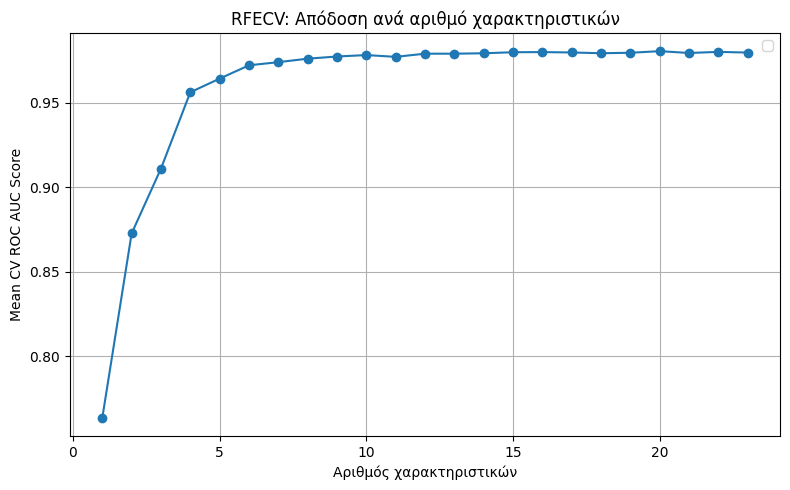

Επιλεγμένα χαρακτηριστικά:
Flight Distance
Arrival Delay in Minutes
Age
Inflight wifi service
Departure/Arrival time convenient
Ease of Online booking
Online boarding
Seat comfort
Inflight entertainment
On-board service
Leg room service
Baggage handling
Checkin service
Inflight service
Cleanliness
Customer Type
Type of Travel
Class_0
Class_1
Class_2


In [ ]:
from lightgbm import LGBMClassifier
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('bin', 'passthrough', binary_features),
        ('nom', OneHotEncoder(handle_unknown='ignore'), categorical_nominal)
    ]
)
clf = LGBMClassifier(
    max_depth=2,
    num_leaves=4,
    learning_rate=0.2,
    n_estimators=50,
    reg_alpha=10,
    reg_lambda=10,
    min_child_samples=100,
    subsample=0.5,
    colsample_bytree=0.5
)

cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=2)
rfecv=RFECV(estimator=clf,cv=cv,scoring='roc_auc')

pipeline=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('feature_selection',rfecv)
    ]
)
pipeline.fit(x,y)
selector=pipeline.named_steps['feature_selection']
scores=selector.cv_results_['mean_test_score']

for i,score in enumerate(scores,start=1):
  print(f"{i} χαρακτηριστικά -> mean CV score: {score:.4f}")
scores=selector.cv_results_['mean_test_score']
best_n=selector.n_features_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(scores) + 1), scores, marker='o', linestyle='-')
plt.xlabel("Αριθμός χαρακτηριστικών")
plt.ylabel("Mean CV ROC AUC Score")
plt.title("RFECV: Απόδοση ανά αριθμό χαρακτηριστικών")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

preprocessor.fit(x)
num_features = preprocessor.named_transformers_['num'].get_feature_names_out(numeric_features)
bin_features = binary_features
nom_features = preprocessor.named_transformers_['nom'].get_feature_names_out(categorical_nominal)
all_feature_names = np.concatenate([num_features, bin_features, nom_features])
selected_mask = selector.support_
feature_ranks = selector.ranking_
selected_features = all_feature_names[selector.support_]
print("Επιλεγμένα χαρακτηριστικά:")
for f in selected_features:
    print(f)




1 χαρακτηριστικά -> mean CV score: 0.7622
2 χαρακτηριστικά -> mean CV score: 0.8898
3 χαρακτηριστικά -> mean CV score: 0.9275
4 χαρακτηριστικά -> mean CV score: 0.9518
5 χαρακτηριστικά -> mean CV score: 0.9602
6 χαρακτηριστικά -> mean CV score: 0.9694
7 χαρακτηριστικά -> mean CV score: 0.9694
8 χαρακτηριστικά -> mean CV score: 0.9744
9 χαρακτηριστικά -> mean CV score: 0.9740
10 χαρακτηριστικά -> mean CV score: 0.9761
11 χαρακτηριστικά -> mean CV score: 0.9757
12 χαρακτηριστικά -> mean CV score: 0.9768
13 χαρακτηριστικά -> mean CV score: 0.9767
14 χαρακτηριστικά -> mean CV score: 0.9777
15 χαρακτηριστικά -> mean CV score: 0.9778
16 χαρακτηριστικά -> mean CV score: 0.9785
17 χαρακτηριστικά -> mean CV score: 0.9783
18 χαρακτηριστικά -> mean CV score: 0.9776
19 χαρακτηριστικά -> mean CV score: 0.9780
20 χαρακτηριστικά -> mean CV score: 0.9766
21 χαρακτηριστικά -> mean CV score: 0.9775
22 χαρακτηριστικά -> mean CV score: 0.9772
23 χαρακτηριστικά -> mean CV score: 0.9777


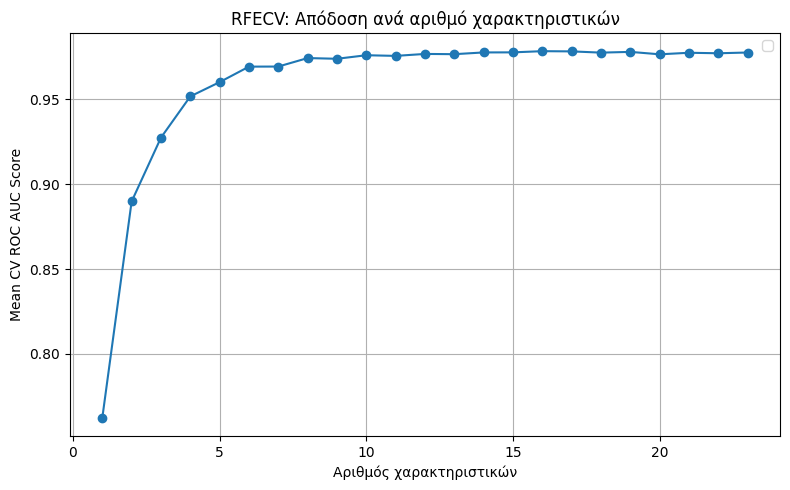

Επιλεγμένα χαρακτηριστικά:
Arrival Delay in Minutes
Inflight wifi service
Departure/Arrival time convenient
Ease of Online booking
Online boarding
Seat comfort
Inflight entertainment
On-board service
Leg room service
Baggage handling
Checkin service
Inflight service
Customer Type
Type of Travel
Class_0
Class_1


In [ ]:
import xgboost as xgb

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('bin', 'passthrough', binary_features),
        ('nom', OneHotEncoder(handle_unknown='ignore'), categorical_nominal)
    ]
)
clf = xgb.XGBClassifier(
    max_depth=2,
    learning_rate=0.3,
    n_estimators=30,
    subsample=0.5,
    colsample_bytree=0.5,
    reg_alpha=10,
    reg_lambda=10,
    min_child_weight=50,
    gamma=5,
    eval_metric='logloss',
    random_state=42
)

cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=2)
rfecv=RFECV(estimator=clf,cv=cv,scoring='roc_auc')

pipeline=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('feature_selection',rfecv)
    ]
)
pipeline.fit(x,y)
selector=pipeline.named_steps['feature_selection']
scores=selector.cv_results_['mean_test_score']

for i,score in enumerate(scores,start=1):
  print(f"{i} χαρακτηριστικά -> mean CV score: {score:.4f}")
scores=selector.cv_results_['mean_test_score']
best_n=selector.n_features_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(scores) + 1), scores, marker='o', linestyle='-')
plt.xlabel("Αριθμός χαρακτηριστικών")
plt.ylabel("Mean CV ROC AUC Score")
plt.title("RFECV: Απόδοση ανά αριθμό χαρακτηριστικών")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

preprocessor.fit(x)
num_features = preprocessor.named_transformers_['num'].get_feature_names_out(numeric_features)
bin_features = binary_features
nom_features = preprocessor.named_transformers_['nom'].get_feature_names_out(categorical_nominal)
all_feature_names = np.concatenate([num_features, bin_features, nom_features])
selected_mask = selector.support_
feature_ranks = selector.ranking_
selected_features = all_feature_names[selector.support_]
print("Επιλεγμένα χαρακτηριστικά:")
for f in selected_features:
    print(f)



1 χαρακτηριστικά -> mean CV score: 0.7132
2 χαρακτηριστικά -> mean CV score: 0.8772
3 χαρακτηριστικά -> mean CV score: 0.9103
4 χαρακτηριστικά -> mean CV score: 0.9212
5 χαρακτηριστικά -> mean CV score: 0.9322
6 χαρακτηριστικά -> mean CV score: 0.9464
7 χαρακτηριστικά -> mean CV score: 0.9484
8 χαρακτηριστικά -> mean CV score: 0.9526
9 χαρακτηριστικά -> mean CV score: 0.9555
10 χαρακτηριστικά -> mean CV score: 0.9582
11 χαρακτηριστικά -> mean CV score: 0.9582
12 χαρακτηριστικά -> mean CV score: 0.9581
13 χαρακτηριστικά -> mean CV score: 0.9580
14 χαρακτηριστικά -> mean CV score: 0.9592
15 χαρακτηριστικά -> mean CV score: 0.9596
16 χαρακτηριστικά -> mean CV score: 0.9600
17 χαρακτηριστικά -> mean CV score: 0.9605
18 χαρακτηριστικά -> mean CV score: 0.9605
19 χαρακτηριστικά -> mean CV score: 0.9606
20 χαρακτηριστικά -> mean CV score: 0.9606
21 χαρακτηριστικά -> mean CV score: 0.9606
22 χαρακτηριστικά -> mean CV score: 0.9606
23 χαρακτηριστικά -> mean CV score: 0.9606


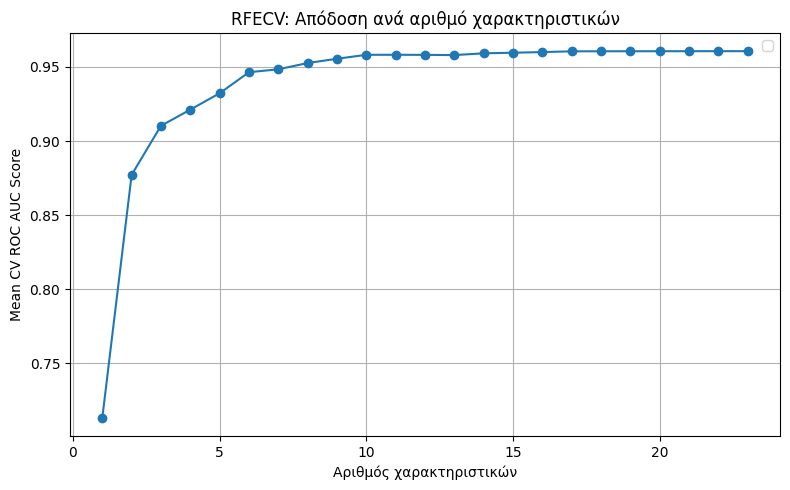

Επιλεγμένα χαρακτηριστικά:
Flight Distance
Arrival Delay in Minutes
Age
Inflight wifi service
Departure/Arrival time convenient
Ease of Online booking
Gate location
Food and drink
Online boarding
Seat comfort
Inflight entertainment
On-board service
Leg room service
Baggage handling
Checkin service
Inflight service
Cleanliness
Gender
Customer Type
Type of Travel
Class_0
Class_1
Class_2


In [ ]:
from sklearn import svm
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features),
        ('nom', OneHotEncoder(handle_unknown='ignore'), categorical_nominal)
    ]
)
clf =svm.SVC(
    kernel='linear',
    C=0.01,
)
cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=2)
rfecv=RFECV(estimator=clf,cv=cv,scoring='roc_auc')

pipeline=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('feature_selection',rfecv)
    ]
)
pipeline.fit(x,y)
selector=pipeline.named_steps['feature_selection']
scores=selector.cv_results_['mean_test_score']

for i,score in enumerate(scores,start=1):
  print(f"{i} χαρακτηριστικά -> mean CV score: {score:.4f}")
scores=selector.cv_results_['mean_test_score']
best_n=selector.n_features_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(scores) + 1), scores, marker='o', linestyle='-')
plt.xlabel("Αριθμός χαρακτηριστικών")
plt.ylabel("Mean CV ROC AUC Score")
plt.title("RFECV: Απόδοση ανά αριθμό χαρακτηριστικών")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

preprocessor.fit(x)
num_features = preprocessor.named_transformers_['num'].get_feature_names_out(numeric_features)
bin_features = binary_features
nom_features = preprocessor.named_transformers_['nom'].get_feature_names_out(categorical_nominal)
all_feature_names = np.concatenate([num_features, bin_features, nom_features])
selected_mask = selector.support_
feature_ranks = selector.ranking_
selected_features = all_feature_names[selector.support_]
print("Επιλεγμένα χαρακτηριστικά:")
for f in selected_features:
    print(f)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features),
        ('nom', OneHotEncoder(handle_unknown='ignore'), categorical_nominal)
    ]
)
X_transformed = preprocessor.fit_transform(x)

In [ ]:
import numpy as np

ohe = preprocessor.named_transformers_['nom']
ohe_feature_names = ohe.get_feature_names_out(categorical_nominal)
feature_names = numeric_features + binary_features + list(ohe_feature_names)
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)
print(X_transformed_df)


       Flight Distance  Arrival Delay in Minutes       Age  \
0             0.679754                 -0.393652 -1.308954   
1            -0.579313                 -0.393652 -1.240902   
2             1.279680                 -0.393652  0.596507   
3             0.865168                 -0.393652  0.528455   
4            -0.575430                 -0.181300 -2.261685   
...                ...                       ...       ...   
29995        -1.027801                 -0.393652  0.188194   
29996        -0.803557                 -0.287476 -0.015963   
29997        -0.543395                 -0.393652 -0.968693   
29998         0.198260                 -0.393652 -0.764537   
29999        -0.709394                  0.110684 -0.084015   

       Inflight wifi service  Departure/Arrival time convenient  \
0                  -1.463944                          -0.859443   
1                  -0.687741                          -1.579224   
2                  -1.463944                          

In [ ]:
import pandas as pd
import numpy as np
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn import svm
from sklearn.neural_network import MLPClassifier
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


Αναλυτικά αποτελέσματα ROC AUC για κάθε αριθμό χαρακτηριστικών:

1 χαρακτηριστικά -> mean CV score: 0.8344
2 χαρακτηριστικά -> mean CV score: 0.8878
3 χαρακτηριστικά -> mean CV score: 0.9151
4 χαρακτηριστικά -> mean CV score: 0.9339
5 χαρακτηριστικά -> mean CV score: 0.9675
6 χαρακτηριστικά -> mean CV score: 0.9733
7 χαρακτηριστικά -> mean CV score: 0.9775
8 χαρακτηριστικά -> mean CV score: 0.9797
9 χαρακτηριστικά -> mean CV score: 0.9810
10 χαρακτηριστικά -> mean CV score: 0.9822
11 χαρακτηριστικά -> mean CV score: 0.9826
12 χαρακτηριστικά -> mean CV score: 0.9826
13 χαρακτηριστικά -> mean CV score: 0.9829
14 χαρακτηριστικά -> mean CV score: 0.9826
15 χαρακτηριστικά -> mean CV score: 0.9824
16 χαρακτηριστικά -> mean CV score: 0.9822
17 χαρακτηριστικά -> mean CV score: 0.9819
18 χαρακτηριστικά -> mean CV score: 0.9812
19 χαρακτηριστικά -> mean CV score: 0.9806
20 χαρακτηριστικά -> mean CV score: 0.9800
21 χαρακτηριστικά -> mean CV score: 0.9794
22 χαρακτηριστικά -> mean CV score: 0.97

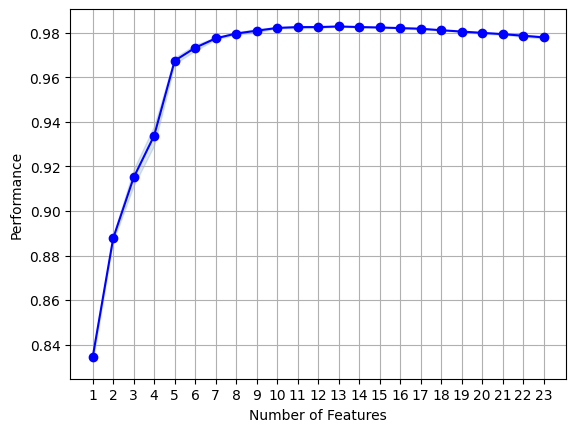

In [ ]:
sfs1 = SFS(svm.SVC(kernel='poly',C=0.1),
           k_features = X_transformed_df.shape[1],
           forward = True,
           floating = True,
           scoring = 'roc_auc',
           cv = 3)
sfs1.fit(X_transformed_df,y)
df_SFS_results=pd.DataFrame(sfs1.subsets_).transpose()

print("\nΑναλυτικά αποτελέσματα ROC AUC για κάθε αριθμό χαρακτηριστικών:\n")
for k in df_SFS_results.index:
    num_feats = len(df_SFS_results.loc[k, 'feature_idx'])
    score = df_SFS_results.loc[k, 'avg_score']
    print(f"{num_feats} χαρακτηριστικά -> mean CV score: {score:.4f}")

fig4 = plot_sfs(sfs1.get_metric_dict(), kind='std_dev')
plt.grid()
plt.show()



Αναλυτικά αποτελέσματα ROC AUC για κάθε αριθμό χαρακτηριστικών:

1 χαρακτηριστικά -> mean CV score: 0.8347
2 χαρακτηριστικά -> mean CV score: 0.8765
3 χαρακτηριστικά -> mean CV score: 0.9223
4 χαρακτηριστικά -> mean CV score: 0.9613
5 χαρακτηριστικά -> mean CV score: 0.9699
6 χαρακτηριστικά -> mean CV score: 0.9745
7 χαρακτηριστικά -> mean CV score: 0.9773
8 χαρακτηριστικά -> mean CV score: 0.9784
9 χαρακτηριστικά -> mean CV score: 0.9805
10 χαρακτηριστικά -> mean CV score: 0.9813
11 χαρακτηριστικά -> mean CV score: 0.9817
12 χαρακτηριστικά -> mean CV score: 0.9820
13 χαρακτηριστικά -> mean CV score: 0.9820
14 χαρακτηριστικά -> mean CV score: 0.9819
15 χαρακτηριστικά -> mean CV score: 0.9817
16 χαρακτηριστικά -> mean CV score: 0.9815
17 χαρακτηριστικά -> mean CV score: 0.9814
18 χαρακτηριστικά -> mean CV score: 0.9812
19 χαρακτηριστικά -> mean CV score: 0.9811
20 χαρακτηριστικά -> mean CV score: 0.9809
21 χαρακτηριστικά -> mean CV score: 0.9807
22 χαρακτηριστικά -> mean CV score: 0.98

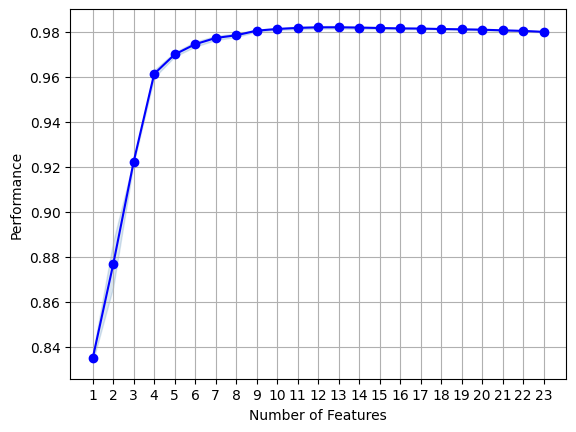

In [ ]:
sfs2 = SFS(svm.SVC(kernel='rbf',C=0.1),
           k_features = X_transformed_df.shape[1],
           forward = True,
           floating = True,
           scoring = 'roc_auc',
           cv = 3)
sfs2.fit(X_transformed_df,y)
df_SFS_results2=pd.DataFrame(sfs2.subsets_).transpose()
print("\nΑναλυτικά αποτελέσματα ROC AUC για κάθε αριθμό χαρακτηριστικών:\n")
for k in df_SFS_results2.index:
    num_feats = len(df_SFS_results2.loc[k, 'feature_idx'])
    score2 = df_SFS_results2.loc[k, 'avg_score']
    print(f"{num_feats} χαρακτηριστικά -> mean CV score: {score2:.4f}")

fig2 = plot_sfs(sfs2.get_metric_dict(), kind='std_dev')
plt.grid()
plt.show()


In [ ]:
sfs3= SFS(svm.SVC(kernel='sigmoid',C=0.1),
           k_features = X_transformed_df.shape[1],
           forward = True,
           floating = True,
           scoring = 'roc_auc',
           cv = 3)
sfs3.fit(X_transformed_df,y)
df_SFS_results3=pd.DataFrame(sfs3.subsets_).transpose()
print("\nΑναλυτικά αποτελέσματα ROC AUC για κάθε αριθμό χαρακτηριστικών:\n")
for k in df_SFS_results3.index:
    num_feats = len(df_SFS_results3.loc[k, 'feature_idx'])
    score3 = df_SFS_results3.loc[k, 'avg_score']
    print(f"{num_feats} χαρακτηριστικά -> mean CV score: {score3:.4f}")

fig3 = plot_sfs(sfs3.get_metric_dict(), kind='std_dev')
plt.grid()
plt.show()


NameError: name 'SFS' is not defined


Αναλυτικά αποτελέσματα ROC AUC για κάθε αριθμό χαρακτηριστικών:

1 χαρακτηριστικά -> mean CV score: 0.8344
2 χαρακτηριστικά -> mean CV score: 0.8992
3 χαρακτηριστικά -> mean CV score: 0.9492
4 χαρακτηριστικά -> mean CV score: 0.9710
5 χαρακτηριστικά -> mean CV score: 0.9788
6 χαρακτηριστικά -> mean CV score: 0.9827
7 χαρακτηριστικά -> mean CV score: 0.9874
8 χαρακτηριστικά -> mean CV score: 0.9887
9 χαρακτηριστικά -> mean CV score: 0.9898
10 χαρακτηριστικά -> mean CV score: 0.9900
11 χαρακτηριστικά -> mean CV score: 0.9899
12 χαρακτηριστικά -> mean CV score: 0.9894
13 χαρακτηριστικά -> mean CV score: 0.9900
14 χαρακτηριστικά -> mean CV score: 0.9897
15 χαρακτηριστικά -> mean CV score: 0.9906
16 χαρακτηριστικά -> mean CV score: 0.9902
17 χαρακτηριστικά -> mean CV score: 0.9902
18 χαρακτηριστικά -> mean CV score: 0.9899
19 χαρακτηριστικά -> mean CV score: 0.9908
20 χαρακτηριστικά -> mean CV score: 0.9906
21 χαρακτηριστικά -> mean CV score: 0.9896
22 χαρακτηριστικά -> mean CV score: 0.99

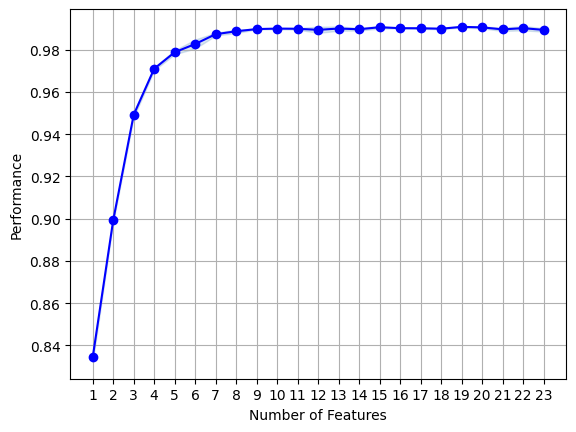

In [ ]:
sfs4 = SFS(
    estimator=MLPClassifier(max_iter=300, early_stopping=True),
    k_features=X_transformed_df.shape[1],
    forward=True,
    floating=True,
    scoring='roc_auc',
    cv=3
)
sfs4.fit(X_transformed_df,y)
df_SFS_results4=pd.DataFrame(sfs4.subsets_).transpose()
print("\nΑναλυτικά αποτελέσματα ROC AUC για κάθε αριθμό χαρακτηριστικών:\n")
for k in df_SFS_results4.index:
    num_feats = len(df_SFS_results4.loc[k, 'feature_idx'])
    score4 = df_SFS_results4.loc[k, 'avg_score']
    print(f"{num_feats} χαρακτηριστικά -> mean CV score: {score4:.4f}")

fig4 = plot_sfs(sfs4.get_metric_dict(), kind='std_dev')
plt.grid()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro


Αναλυτικά αποτελέσματα ROC AUC για κάθε αριθμό χαρακτηριστικών:

1 χαρακτηριστικά -> mean CV score: 0.8344
2 χαρακτηριστικά -> mean CV score: 0.8856
3 χαρακτηριστικά -> mean CV score: 0.9432
4 χαρακτηριστικά -> mean CV score: 0.9639
5 χαρακτηριστικά -> mean CV score: 0.9720
6 χαρακτηριστικά -> mean CV score: 0.9810
7 χαρακτηριστικά -> mean CV score: 0.9833
8 χαρακτηριστικά -> mean CV score: 0.9847
9 χαρακτηριστικά -> mean CV score: 0.9848
10 χαρακτηριστικά -> mean CV score: 0.9846
11 χαρακτηριστικά -> mean CV score: 0.9856
12 χαρακτηριστικά -> mean CV score: 0.9858
13 χαρακτηριστικά -> mean CV score: 0.9862
14 χαρακτηριστικά -> mean CV score: 0.9862
15 χαρακτηριστικά -> mean CV score: 0.9859
16 χαρακτηριστικά -> mean CV score: 0.9879
17 χαρακτηριστικά -> mean CV score: 0.9865
18 χαρακτηριστικά -> mean CV score: 0.9874
19 χαρακτηριστικά -> mean CV score: 0.9874
20 χαρακτηριστικά -> mean CV score: 0.9879
21 χαρακτηριστικά -> mean CV score: 0.9871
22 χαρακτηριστικά -> mean CV score: 0.98

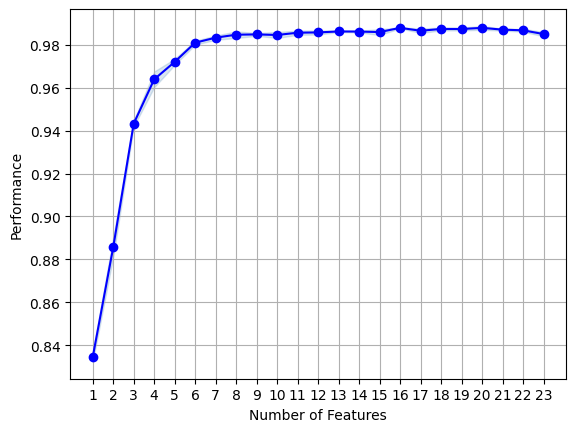

In [ ]:
sfs4 = SFS(
    estimator=MLPClassifier(hidden_layer_sizes=(10,), max_iter=100, early_stopping=True),
    k_features=X_transformed_df.shape[1],
    forward=True,
    floating=True,
    scoring='roc_auc',
    cv=3
)
sfs4.fit(X_transformed_df,y)
df_SFS_results4=pd.DataFrame(sfs4.subsets_).transpose()
print("\nΑναλυτικά αποτελέσματα ROC AUC για κάθε αριθμό χαρακτηριστικών:\n")
for k in df_SFS_results4.index:
    num_feats = len(df_SFS_results4.loc[k, 'feature_idx'])
    score4 = df_SFS_results4.loc[k, 'avg_score']
    print(f"{num_feats} χαρακτηριστικά -> mean CV score: {score4:.4f}")

fig4 = plot_sfs(sfs4.get_metric_dict(), kind='std_dev')
plt.grid()
plt.show()
